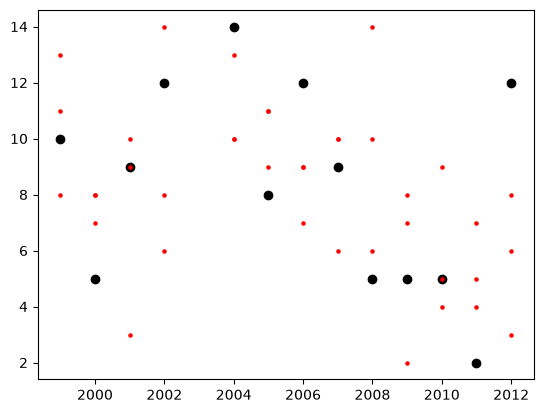

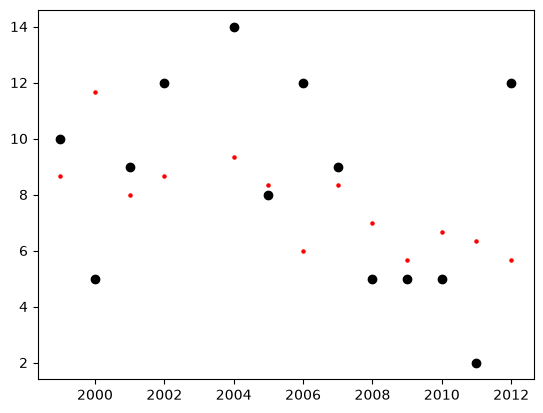

    Year  sample 0  sample 1  sample 2
0   2011         6         9         4
1   2010         9         7         4
2   2002         6        13         7
3   2006         9         2         7
4   2008         4        10         7
5   2012         9         5         3
6   2000        11        12        12
7   2005        11         9         5
8   2007         5        12         8
9   2004        11        10         7
10  1999         4        13         9
11  2001         9         9         6
12  2009         7         5         5


In [5]:

'''
Generalized Linear Regression for Poisson Distribution
This file must be in a folder called Exercises, and the data file must be in a subfolder called data. It will generate a scatter plot of the actual values and the predicted values, and save it as a jpeg file. It will also save the predicted values as a csv file. Both located in the Exercises folder.
'''

import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.stats import poisson

# relative filepath for main folder
folder_path = ""
# relative filepath for datafile
path = folder_path + "data/bird_count.csv"


# Read the data
file = pd.read_csv(path)
Years = file["yr"]
counts = file["count"]
max_year = Years.max()
Years /= max_year

def log_likely(beta):
    '''
    Computes the log-likelihood of the Poisson regression model given the parameters beta.
    '''
    x = Years
    y = counts
    n = len(Years)
    beta_0, beta_1 = beta
    eta = beta_0 + beta_1 * Years

    log_likelihood = np.sum(
        -np.exp(eta) + counts * eta
    )

    return log_likelihood

# Find the optimal beta parameters by maximizing the log-likelihood function
optimal_beta = minimize(lambda beta: -1*log_likely(beta), [1,1]).x

def single_prediction(year,n=1):
    '''
    Predicts n samples for a given year. Returns an array of shape (n,) containing the predicted samples.
    '''
    x=year/max_year
    beta_0, beta_1 = optimal_beta
    lambd = np.exp(beta_0 + beta_1*x)
    samples = poisson.rvs(mu=lambd,size=n)
    return samples

def prediction(year,n=1):
    '''
    Predicts n samples for each year in the input array of years. Returns a 2D array of shape (len(year), n) where each row corresponds to a year and each column corresponds to a sample.
    '''
    preds = []
    for y in year:
        pred = single_prediction(y,n)
        preds.append(pred)
    return np.array(preds)


# Scatter plot of actual values
actual_ys = Years*max_year

ys = np.linspace(1999,2012,50)

def scatter_many(years,n):
    '''
    Scatter plot of actual values and predicted values, for n samples
    '''
    plt.scatter(actual_ys,counts,c="Black")
    predictions = prediction(years,n)
    for _ in range(n):
        plt.scatter(years,predictions[:,_],c="Red",s=5)
    plt.savefig(folder_path + "Poisson.jpeg")
    plt.show()
    
    data = {}
    for i in range(n):
        data[f"sample {i}"] = predictions[:,i]
    pd.DataFrame(data).to_csv(folder_path + "Poisson_regression_sampels.csv", index = False)
    
def scatter_mean(years,n):
    '''
    Scatter plot of actual values and mean of predicted values, for n samples
    '''
    plt.scatter(actual_ys,counts,c="Black")
    predictions = prediction(years,n)
    means = np.mean(predictions, axis=1)
    
    plt.scatter(years,means,c="Red",s=5)
    plt.savefig(folder_path + "Poisson_mean.jpeg")
    plt.show()
    
    data = {}
    data["Year"] = [int(year) for year in years]
    for i in range(n):
        data[f"sample {i}"] = predictions[:,i]
    pd.DataFrame(data).to_csv(folder_path + "Poisson_regression_sampels.csv", index = False)
    print(pd.DataFrame(data))

scatter_many(actual_ys,3)
scatter_mean(actual_ys,3)

